# Processing glacier seismic data with HVSRpy


## Authors:
* Koen Van Noten ([@KoenVanNoten](https://github.com/KoenVanNoten))
* Thomas Lecocq ([@seismotom](https://github.com/ThomasLecocq))

## Introduction:
Three-component __seismic nodes__ are conquering the world these days as lightweight smart seismic sensors. This notebook provides a guideline how to handle seismic node data and perform H/V spectral ratio analysis of ambient noise (mHVSR of HVSRN) recorded with seismic nodes. We'll show you some methods:
* how to perform mHVSR using hvsrpy
* how to do the same exercise automatically 
* and we'll open the discussion towards an interpretation of the results. 

## Citation

If you use _hvsrpy_ in your research or consulting, we ask you please cite the following:

> Vantassel, J.P. (2025). "_hvsrpy_: An Open‐Source Python Package for Microtremor
> and Earthquake Horizontal‐to‐Vertical Spectral Ratio Processing". Seismological
> Research Letters. 96 (4): 2671–2682,
> [https://doi.org/10.1785/0220240395](https://doi.org/10.1785/0220240395)

The essential codes to analyse the output data in this notebook are based on the following paper:
> Van Noten, K., Lecocq, T., Goffin, C., Meyvis, B., Molron, J., Debacker, T.N. & Devleeschouwer, X. 2022. Brussels’ 
> bedrock paleorelief from borehole-controlled powerlaws linking polarised H/V resonance frequencies and sediment 
> thickness. _Journal of Seismology_ 26, 35-55. 
> https://doi.org/10.1007/s10950-021-10039-8  > https://publi2-as.oma.be/record/5626/files/2022_VanNotenetal_HVSR_Powerlaw_Brussels.pdf 

The codes results from:
> Van Noten, K, Lecocq, Buddha Power, B. (2020). HVSR to Virtual Borehole (1.0). Zenodo.
> https://doi.org/10.5281/zenodo.4276310

In [1]:
import hvsrpy
import obspy
import pathlib
import time
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime
import matplotlib.colors as colors
from matplotlib.collections import LineCollection
from obspy import UTCDateTime, read, Stream
from HVSR_minionology import *

# use ipython notebook in a wider screen
from IPython.display import display, HTML
display(HTML("<style>.jp-Notebook{max-width:100%!important}.container{width:95%!important}#notebook-container{width:95%!important}</style>"))

################ some definitions

def preprocessing(detrend, window_length, degrees_from_north, filter_corner_frequencies_in_hz, ignore_dissimilar_time_step_warning):
    preprocessing_settings = hvsrpy.settings.HvsrPreProcessingSettings()
    preprocessing_settings.detrend = detrend
    preprocessing_settings.window_length_in_seconds = window_length
    preprocessing_settings.orient_to_degrees_from_north = degrees_from_north
    preprocessing_settings.filter_corner_frequencies_in_hz = filter_corner_frequencies_in_hz
    preprocessing_settings.ignore_dissimilar_time_step_warning = ignore_dissimilar_time_step_warning

    #preprocessing_settings.psummary()

    return preprocessing_settings

def processing(window_type, window_width, smoothing_operator, smoothing_bandwidth, freq_min, freq_max, steps, method_to_combine_horizontals, handle_dissimilar_time_steps_by):
    processing_settings = hvsrpy.settings.HvsrTraditionalProcessingSettings()
    processing_settings.window_type_and_width = (window_type, window_width)
    processing_settings.smoothing=dict(operator=smoothing_operator,
                                       bandwidth=smoothing_bandwidth,
                                       center_frequencies_in_hz=np.geomspace(freq_min, freq_max, steps))
    processing_settings.method_to_combine_horizontals = method_to_combine_horizontals
    processing_settings.handle_dissimilar_time_steps_by = handle_dissimilar_time_steps_by
    #processing_settings.psummary()
    
    return processing_settings

def read_files(directory, SDS, year, network, station, comp, days):
    zfiles = sorted(glob.glob(os.path.join(directory, SDS, year,network,station,"*%s.D"%comp,days)))
    return np.unique([f.replace("%s.D"%comp,"*.D") for f in zfiles])

## NOTEBOOK 21: Is the average HVSR of one day sufficient to understand what's happening on a glacier?
No, would be better to have the HVSR evolution with time. Let's use Obspy to split a day pattern in hourly data, compute the HVSR and then evaluate the HVSR variability with time.

## DATA AND OUTPUT
As seen in previous notebooks, data comes from seismic data gathered from the Grenzgletscher, Switserland, in the Monta Rosa Massif. Data is property of Joachim Wasserman (LMU).  

In [2]:
## add you data path
DATA_PATH = '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/'

In [3]:
# create data and output paths
output_folder = os.path.join(DATA_PATH, 'Analysed') 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
print(DATA_PATH)
print(output_folder)

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed


In [4]:
### Let's go cryoseismology
### choose station: ADR1, BB01, C16, C17, C29, C2A, C65, C66, C67, C68, C69, C6A, S35, UP1, UP2, UP3, UP4, UP5, UP6
SDS  ='SDS'
year = '2024'
network = 'XG'
station = 'BB01'
day = '*' # select a day, four days are available 079, 080, 081, 082, OR '*' for all days (not recommend for big SDS archives)

#########
zfiles = sorted(glob.glob(os.path.join(DATA_PATH, SDS, year, network, station, "*Z.D",'*.%s'%day)))
files = np.unique([f.replace("Z.D","*.D") for f in zfiles])
files

array(['/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HH*.D/XG.BB01..HH*.D.2024.079',
       '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HH*.D/XG.BB01..HH*.D.2024.080',
       '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HH*.D/XG.BB01..HH*.D.2024.081',
       '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HH*.D/XG.BB01..HH*.D.2024.082'],
      dtype='<U155')

### HVSR Preprocessing Settings
- **Detrending**: `constant` - Remove mean from time series
- **Window Length**: `120` seconds - Duration of each time window for analysis
- **Orientation**: `None` - No rotation of horizontal components
- **Filter Corner Frequencies**: `(None, None)` Hz - No bandpass filtering applied
- **Ignore Time Step Warning**: `False` - Warnings enabled for dissimilar sampling rates

### HVSR Windowing - Smoothing - Freq domain Settings
- **Window Type**: `tukey` - Tapered cosine window
- **Window Width**: `0.05` - Taper fraction (5% of window at each end)
- **Smoothing Operator**: `konno_and_ohmachi` - Logarithmic smoothing
- **Smoothing Bandwidth**: `40` - Smoothing parameter (higher = more smoothing)
- **Minimum Frequency**: `1` Hz - Choose
- **Maximum Frequency**: `100` Hz - Choose
- **Number of Steps**: `1000` - Frequency resolution points

### HVSR Processing Methods
- **Horizontal Combination Method**: `geometric_mean` - Combine NS and EW components using geometric mean
- **Time Step Handling**: `frequency_domain_resampling` - Resample in frequency domain if sampling rates differ

In [5]:
### Preprocessing Settings
detrend = "constant"
window_length = 120
orient_to_degrees_from_north = None
filter_corner_frequencies_in_hz = (None, None)
ignore_dissimilar_time_step_warning = False

preprocessing_settings = preprocessing(detrend, window_length, orient_to_degrees_from_north, filter_corner_frequencies_in_hz, ignore_dissimilar_time_step_warning)

# Processing settings
window_type = "tukey"
window_width = 0.05
smoothing_operator = "konno_and_ohmachi"
smoothing_bandwidth = 40
freq_min = 0.2
freq_max = 50
steps = 500
method_to_combine_horizontals = "geometric_mean"
handle_dissimilar_time_steps_by = "frequency_domain_resampling"

processing_settings = processing(window_type, window_width, smoothing_operator, smoothing_bandwidth, freq_min, freq_max, steps, method_to_combine_horizontals, handle_dissimilar_time_steps_by)

## HVSR Processing Loop strategy

### Processing Configuration
- **Processing Window Length**: `3600` seconds (1 hour) - Data is split into hourly segments
- **Force Overwrite**: `True` - Existing output files will be overwritten
- **Apply Cox et al. 2020 Rejection Filter**: `True`
  - **n parameter**: `2` standard deviations
  - **Search Range**: `(0.2, 100)` Hz - Frequency range for peak detection

### Processing Workflow
For each seismic data file, the script performs the following steps:

#### 1. **File Preparation**
- Extract node ID from filename
- Ospy: Read and merge seismic stream (interpolating gaps)
- Obspy: Align start time to full hour boundaries
- Obspy: Define station identifier from network and station codes

#### 2. **Hourly Segmentation**
- Split continuous data into 1-hour windows
- Check if output `.hv` file already exists
- Skip processing if file exists (unless `force=True`)

#### 3. **HVSR Processing** (for each hourly segment)
- Trim stream to current hour
- Export temporary `.mseed` file for hvsrpy compatibility
- Read data using `hvsrpy.read()`
- Apply preprocessing settings
- Process HVSR curves

#### 4. **Window Rejection Statistics**
- Count valid windows **before** Cox rejection
- Apply frequency-domain window rejection (if enabled)
- Count valid windows **after** Cox rejection
- Display rejection statistics:
  - Valid windows before/after filtering
  - Number of rejected windows
  - Total number of curves processed

#### 5. **Output**
- Generate HVSR statistics summary
- Export results to Geopsy `.hv` format
- Organize outputs by node ID in separate folders

---

### Output File Naming Convention
Format: `{station}.{YYYYMMDDHHMMSS}.hv`

Example: `XX_STA01.202401151300.hv` (data from 2024-01-15 at 13:00:00 to 14:00:00)

In [6]:
#### select how you want to split, e.? 3600 = hourly files
process_len = 3600

### want to force and overwrite previous runs? Choose False if data already exists
force = True

## apply Cox et al 2020 rejection filter?
Cox = True
n = 2
search_range_in_hz = (freq_min,freq_max)

########## Let's go
for file in files:

    node_ID = os.path.split(file)[-1].split('.')[1]
    st = read(file)
    st.merge(method = 1, fill_value = 'interpolate')
    tr = st[0]
    start = tr.stats.starttime
    # go for full hourly data = easier
    if start.minute != 0:
        start = UTCDateTime(start.year, start.month, start.day, start.hour + 1)
    end = tr.stats.endtime
    station = '%s_%s'%(tr.stats.network, tr.stats.station)
    
    # Let's cut the stream into hourly data and process these
    for i in np.arange(start, end, process_len):
        print('**********************************')
        time = i
        
        # IF the .hv file already exists for this station, then skip this hour and go to the next hour
        check_hv_name = '%s%02d%02d%02d%02d%#02d'%(time.year, time.month, time.day, time.hour, time.minute, time.second)
        check_HV = os.path.join(output_folder, '{0}/{1}.{2}.hv'.format(node_ID, station, check_hv_name))
        
        if os.path.isfile(check_HV) and not force :
            print(f"Output already exists, skipping: {check_HV}")
        else:
            if os.path.isfile(check_HV):
                print(f"File exists but --force specified, overwriting: {check_HV}")
            else:
                 print(f"Creating new file: {check_HV}")
            
            # Cut the stream for hourly data
            st_cut = st.copy()
            st_cut.trim(starttime=i, endtime=i + process_len)
            print(st_cut)
        
            # We need hvsrpy to work with a datapath, so will store locally an mseed and continue with that
            fn = os.path.join(DATA_PATH, "current.mseed")
            st_cut.write(fn)
            wf = fn

            # create string to save the hourly HVSR file 
            tStart = '%s%02d%02d%02d%02d%#05.2f'%(time.year, time.month, time.day, time.hour, time.minute, time.second)
            tStart_hv = '%s%02d%02d%02d%02d%#02d'%(time.year, time.month, time.day, time.hour, time.minute, time.second)
            endtime = time + process_len
            tEnd = '%s%02d%02d%02d%02d%#05.2f'%(endtime.year, endtime.month, endtime.day, endtime.hour, endtime.minute, endtime.second)
            
            ### Make a folder for each station output
            out_folder = os.makedirs(os.path.join(output_folder,node_ID), exist_ok=True)
            
            ### Let's run
            print(wf)
            srecords = hvsrpy.read([[wf]])
            srecords_preprocessed = hvsrpy.preprocess(srecords, preprocessing_settings)
            hvsr = hvsrpy.process(srecords_preprocessed, processing_settings)
            
            # Before rejection
            n_valid_before = hvsr.valid_window_boolean_mask.sum()
            print(f"Without window rejection: {n_valid_before}/{hvsr.n_curves} windows")

            # Apply rejection filter
            if Cox:
                n = n       
                search_range_in_hz = search_range_in_hz
                rejected = hvsrpy.frequency_domain_window_rejection(hvsr, n=n, search_range_in_hz=search_range_in_hz)
                # THEN check for the attribute
                n_rejected = (~hvsr.valid_window_boolean_mask).sum()
                
                # After rejection - must call .sum() again on the updated mask
                n_valid_after = hvsr.valid_window_boolean_mask.sum()
                n_rejected = (~hvsr.valid_window_boolean_mask).sum()

                # After rejection
                print("AFTER Cox et al. 2020 filtering:")
                print(f"  Valid windows: {n_valid_after}/{hvsr.n_curves}")

                #hvsrpy.summarize_hvsr_statistics(hvsr)
            else: 
                #hvsrpy.summarize_hvsr_statistics(hvsr)
                print('no filter')
                
            hvsrpy_export_to_geopsy_hv(hvsr, check_HV)

**********************************
File exists but --force specified, overwriting: /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/BB01/XG_BB01.20240319000000.hv
3 Trace(s) in Stream:
XG.BB01..HHE | 2024-03-19T00:00:00.000000Z - 2024-03-19T01:00:00.000000Z | 200.0 Hz, 720001 samples
XG.BB01..HHN | 2024-03-19T00:00:00.000000Z - 2024-03-19T01:00:00.000000Z | 200.0 Hz, 720001 samples
XG.BB01..HHZ | 2024-03-19T00:00:00.000000Z - 2024-03-19T01:00:00.000000Z | 200.0 Hz, 720001 samples
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/current.mseed
Without window rejection: 30/30 windows
AFTER Cox et al. 2020 filtering:
  Valid windows: 22/30
Exported to /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/BB01/XG_BB01.20240319000000.hv
**********************************
File exists but --force specifi

## Temporal HVSR Evolution

Plot all HVSR curves for station `stationname` over time with color-coded progression. Play until you are satisfied to go to notebook 22.

- **X-axis**: Hours from first measurement
- **Y-axis**: Frequency (Hz, log scale)
- **Color**: H/V amplitude  (viridis colormap)
- Each curve offset by elapsed time to visualize temporal changes in site resonance
- red dots gives the f0 from the average curve

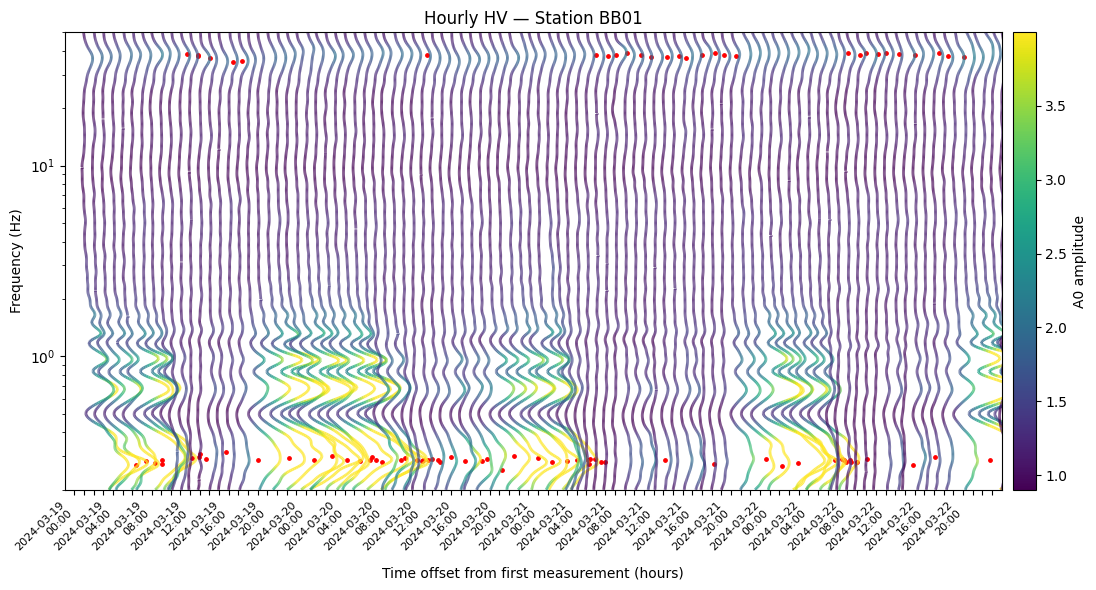

In [7]:
from datetime import datetime

station = 'BB01'

fig, ax = plt.subplots(figsize=(12, 6))

HV_files = glob.glob(os.path.join(output_folder, station, "*.hv"))
HV_files.sort()

# Extract datetimes from filenames
datetimes = []
for HV_file in HV_files:
    filename = os.path.basename(HV_file)
    datetime_str = filename.split('.')[-2]
    dt = datetime.strptime(datetime_str, '%Y%m%d%H%M%S')
    datetimes.append(dt)

t0 = datetimes[0]
time_offsets = [(dt - t0).total_seconds() / 3600 for dt in datetimes]

# Single pass: read all files once
all_data = []
all_A0 = []

for HV_file, dt, offset in zip(HV_files, datetimes, time_offsets):
    Freq, A0, A_min, A_max = read_HV(HV_file)
    all_data.append((Freq, A0, offset))
    all_A0.extend(A0)


# Compute norm once from all A0 values
norm = colors.Normalize(vmin=np.percentile(all_A0, 5), vmax=np.percentile(all_A0, 95))
cmap = cm.viridis

# Single plotting loop
for (Freq, A0, offset), HV_file in zip(all_data, HV_files):
    x = A0 + offset
    points = np.array([x, Freq]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm, alpha=0.8, lw=2)
    lc.set_array(A0[:-1])
    ax.add_collection(lc)
    f0_avg, f0_win, error, A0, nw_avg, nw_win, f_min, f_max = get_params_from_HV(HV_file)
    plt.scatter(A0 + offset, f0_avg, color = 'red', s = 6)
    

# Axis limits (LineCollection doesn't auto-scale)
ax.set_xlim(min(time_offsets) - 1, max(time_offsets) + 1)
ax.set_ylim(min(all_data[0][0]), max(all_data[0][0]))

# X-ticks
ax.set_xticks(time_offsets)
ax.set_xticklabels(
    [dt.strftime('%Y-%m-%d\n%H:%M') if i % 4 == 0 else ''
     for i, dt in enumerate(datetimes)],
    rotation=45, ha='right', fontsize=8
)

ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time offset from first measurement (hours)')
ax.set_title(f'Hourly HV — Station {station}')

# Colorbar for A0
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('A0 amplitude')

plt.tight_layout()
plt.show()